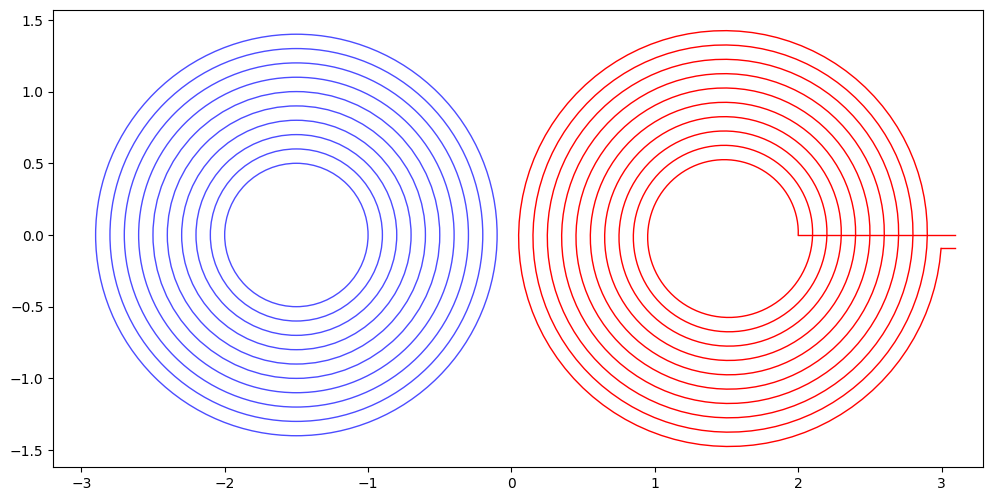

In [1]:
'''
Optimization of magnetic configuration created by two spirals.
'''
import os
from dataclasses import dataclass, fields
from scipy.optimize import minimize
import scipy.integrate as integrate
from itertools import combinations
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.lines as lines

def spiral_demo():
    '''
    A spiral is modeled by a family of concentric circles.  This
    looks okay, because the mean radial current due to the converging
    spiral is compensated by the outgoing straight wire in the opposite
    direction.
    '''
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    for i in range(10):
        ax.add_patch(Circle((-1.5, 0), 0.5+0.1*i, lw=1, alpha=0.7, facecolor='none', edgecolor='blue'))
    tt = np.linspace(0, 20*np.pi, 1000, endpoint=False)
    rr = 0.5 + 1.0*tt/(20*np.pi)
    xx = 1.5 + rr*np.cos(tt)
    yy = 0.0 + rr*np.sin(tt)
    ax.plot(xx, yy, color='red', lw=1)
    ax.add_artist(lines.Line2D([xx[0], xx[-1]+0.1], [yy[0], 0], linewidth=1, color='red'))
    ax.add_artist(lines.Line2D([xx[-1], xx[-1]+0.1], [yy[-1], yy[-1]], linewidth=1, color='red'))
    ax.set_aspect('equal')

spiral_demo()

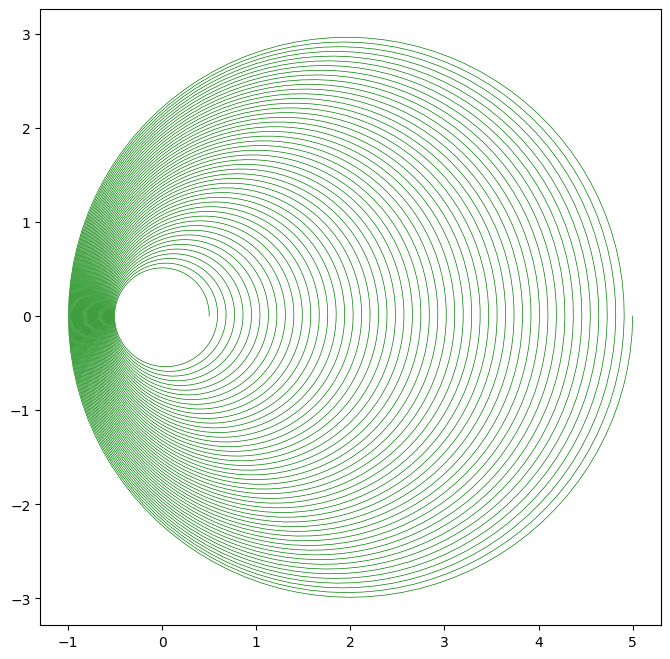

In [2]:
def ex_spiral_demo():
    '''
    Excentric spiral.  Both radius and x-center increase linearly with polar angle.
    '''
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    a, d, ex = 0.5, 2.5, 0.8
    n = 50
    tmax = 2*np.pi*n
    tt = np.linspace(0, tmax, n*100, endpoint=True)
    rr = a + d*tt/(2*np.pi*n)
    xx = d*ex*tt/tmax + rr*np.cos(tt)
    yy = rr*np.sin(tt)
    ax.plot(xx, yy, color='green', lw=0.5)
    ax.set_aspect('equal')

ex_spiral_demo()

### Parameterizing a spiral

An excentric spiral is defined parametrically as follows:
$$
x=x_c(\theta) + R(\theta)\cos(\theta),\quad y=R(\theta)\sin(\theta).
$$
Here the dependence of the radius on the angle, normally linear, is *spirality*, and the dependence of the center on the angle is $excentricity$:
$$
R(\theta)=a + \delta\frac{\theta}{2\pi},\quad x_c(\theta)=\epsilon\frac{\theta}{2\pi},
$$
where $\delta$ is the step of the spiral and $\epsilon<\delta$ is the step of radius per revolution.  The radial density $\rho$ of the loops varies between $\rho_{max}=(\delta-\epsilon)^{-1}$ and $\rho_{min}=(\delta+\epsilon)^{-1}$.  It is possible to compute the field of the spiral, but the result will be very close to that of a family of $N=\theta_{max}/(2\pi)$ circles with centers $x_{ci}=x_c+i\epsilon$ and the radii $R_i=a+id$.

The parameters of a spiral would include:
* $x_c$ - $x$-location of the inner center, $x_c\in[-3,2]\,cm$;
* $z$ - vertical location of the spiral's plane, fixed at -0.1 or -0.2 cm;
* $a$ - inner radius, $a\in[0.2,1.0]\,cm$;
* $d$ - radial range: difference between outer and inner radii, $d\in[2.0,4.0]\,cm$;
* $\delta$ - radius increment per revolution;
* $\xi=\epsilon/\delta$ - excentricity, $|\xi|<1$. If we want to realize the maximum loop density $\rho_{max}=\delta^{-1}(1-|\xi|)^{-1}=4\,cm^{-1}$, the parameter $\delta=0.25/(1-|\xi|)$ is no longer independent.
* The number of loops $n=d/\delta=4d(1-|\xi|)+1$ is then not an integer, but can be rounded to an integer with some discontinuous behavior which could affect `scipy.minimize` but hopefully won't.
* For two spirals, the parameters $(x_c,z,a,d,\xi)$ are set for each spiral, plus we need the ratio of the two currents $I_r=I_2/I_1$.


In [3]:
@dataclass
class Spirals:
    xc1: float = -1     # center of inner circle
    dx: float =  1.0    # xc2 - xc1
    z1: float = -0.01   # z-height of the spiral
    z2: float = -0.02
    a1: float =  0.2    # min_radius
    a2: float =  0.2
    d1: float =  2.0    # max_radius - min_radius
    d2: float =  2.0
    Ir: float = -1.0    # I2/I1
    ex1: float = 0      # excentricity, must be less than 1 by abs value
    ex2: float = 0 
    def n1(self):         return int(np.round(4*self.d1*(1-np.abs(self.ex1)))) # number of revolutions (circles)
    def n2(self):         return int(np.round(4*self.d1*(1-np.abs(self.ex1))))
    def dr1(self):        return 0.25/(1-np.abs(self.ex1))        # radius increment per revolution
    def dr2(self):        return 0.25/(1-np.abs(self.ex2))
    def x1(self, i):      return self.xc1 + self.ex1*i*self.dr1() # center of ith circle
    def x2(self, i):      return self.xc1 + self.ex2*i*self.dr2() + self.dx
    def r1(self, i: int): return self.a1 + i*self.dr1()           # radius of ith circle
    def r2(self, i: int): return self.a2 + i*self.dr2()
    def __str__(self): # make Params object printable
        n = 4 # precision
        return \
        f'x=({round(self.x1(0),n)},{round(self.x2(0),n)}), ' + \
        f'z({round(self.z1,n)},{round(self.z2,n)}), ' + \
        f'a({round(self.a1,n)},{round(self.a2,n)}), ' + \
        f'd({round(self.d1,n)},{round(self.d2,n)}), ' + \
        f'ex({round(self.ex1,n)},{round(self.ex2,n)}), ' + \
        f'n({self.n1()},{self.n2()}), ' + \
        f'Ir={round(self.Ir,n)}'

@dataclass
class SpiralBounds:
    xc1 = (-3, 2)
    dx = (0.1, 3)
    a1 = (0.2, 1)
    a2 = (0.2, 1)
    d1 = (1, 3)
    d2 = (1, 3)
    ex1 = (-0.9, 0.9)
    ex2 = (-0.9, 0.9)
    Ir = (-1, -0.1) # second spiral current opposite and smaller than first
    # z1,z2 fixed

def dB(x, y, z, a, t):
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D3 = D2*np.sqrt(D2)
    bx = a*z*cos/D3
    by = a*z*sin/D3
    bz = a*(a - x*cos - y*sin)/D3
    return np.array([bx, by, bz])

def dB_derivs(x, y, z, a, t):
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D1 = np.sqrt(D2)
    D3 = D2*D1
    D5 = D2*D3
    bxx = -3*a*z*cos*(x - a*cos)/D5
    bxz = a*cos/D3*(1 - 3*z*z/D2)
    bzx = -a*cos/D3 - 3*a*(x - a*cos)*(a - x*cos - y*sin)/D5
    bzz = 3*a*z*(x*cos + y*sin - a)/D5
    return np.array([bxx, bxz, bzx, bzz]) # only some of them

def loop_B(x, y, z, a):
    return integrate.quad_vec(lambda t: dB(x, y, z, a, t), 0, 2*np.pi)[0]

def loop_B_derivs(x, y, z, a):
    return integrate.quad_vec(lambda t: dB_derivs(x, y, z, a, t), 0, 2*np.pi)[0]

def add_to(lhs, rhs):
    return rhs if lhs is None else lhs + rhs

def total_B(x, y, z, spirals): # (Bx, By, Bz)
    B1, B2 = None, None
    for i in range(spirals.n1()): B1=add_to(B1, loop_B(x - spirals.x1(i), y, z - spirals.z1, spirals.r1(i)))
    for i in range(spirals.n2()): B2=add_to(B2, loop_B(x - spirals.x2(i), y, z - spirals.z2, spirals.r2(i)))
    Bx = B1[0] + spirals.Ir*B2[0]
    By = B1[1] + spirals.Ir*B2[1]
    Bz = B1[2] + spirals.Ir*B2[2]
    return np.array([Bx, By, Bz])

def total_B_derivs(x, y, z, spirals):
    D1, D2 = None, None
    for i in range(spirals.n1()): D1=add_to(D1, loop_B_derivs(x - spirals.x1(i), y, z - spirals.z1, spirals.r1(i)))
    for i in range(spirals.n2()): D2=add_to(D2, loop_B_derivs(x - spirals.x2(i), y, z - spirals.z2, spirals.r2(i)))
    return D1 + spirals.Ir*D2 # (Bxx, Bxz, Bzx, Bzz)

def compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz):
    C = Bzz - Bxx
    D = np.sqrt(C*C + 4*Bxz*Bzx)
    evec = (C + D, 2*Bxz) # the other one is (C - D, 2*Bxz)
    return evec

def get_angle(evec): # in [-pi, pi]
    angle = np.atan2(evec[0], evec[1]) # in [-pi, pi]
    if angle < 0:
        angle += np.pi
    if angle > np.pi/2:
        angle -= np.pi/2
    return angle

if True: # introspection of fields in dataclass
    for field in fields(Spirals()):
        print(field.name)


xc1
dx
z1
z2
a1
a2
d1
d2
Ir
ex1
ex2


In [4]:
def search_params(null_x, null_y, null_z, vars):
    pp = Spirals()  # default/initial params
    bb = SpiralBounds()
    angle = None
    def angle_utility(evec):
        nonlocal angle
        angle = get_angle(evec)
        deg = angle*180/np.pi # in [0, 90]
        return ((deg - 36)*(deg - 56)/8100)**2
    def utility(values):
        for var, value in zip(vars, values):
            setattr(pp, var, value) # set pp.<var> = value
        B = total_B(null_x, null_y, null_z, pp)
        field_utility = np.sum(np.square(B))
        Bxx, Bxz, Bzx, Bzz = total_B_derivs(null_x, null_y, null_z, pp)
        evec = compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz)
        return field_utility + angle_utility(evec)
    initial_values = [getattr(pp, var) for var in vars]
    bounds         = [getattr(bb, var) for var in vars]
    result = minimize(utility, initial_values, bounds=bounds)
    return result, angle

def write_result(fname, idx, vars, result, angle):
    pp = Spirals()
    ff = [field.name for field in fields(pp)]
    if not os.path.isfile(fname):
        fp = open(fname, 'w')
        print(f'run,dim,vars,{",".join(ff)},n1,n2,U,angle', file=fp)
    else:
        fp = open(fname, 'a')
    for var, value in zip(vars, result.x):
        setattr(pp, var, value)
    values = [str(getattr(pp, var)) for var in ff]
    print(f'{idx},{len(vars)},{" ".join(vars)},{",".join(values)},{pp.n1()},{pp.n2()},{result.fun},{angle}', file=fp)
    fp.close()

null_x, null_y, null_z = np.array([0.0]), np.array([0.0]), np.array([1.5])

def optimize_over_spiral_combinations(dim, fname=None):
    vars_tuples = list(combinations(['xc1', 'dx', 'a1', 'a2', 'd1', 'd2', 'ex1', 'ex2', 'Ir'], dim))
    results = [] # for each vars_tuple
    for idx, vars in enumerate(vars_tuples):
        result, angle = search_params(null_x, null_y, null_z, vars)
        results.append(result)
        print(f'Run {idx:02d}:  {vars} -> {result.x}: U -> {result.fun}')
        if fname is not None:
            write_result(fname, idx, vars, result, angle*180/np.pi)
    return vars_tuples, results

dim = 5 # how many parameters (out ot 9) to play with at a time.  9 choose 5 is 126.
fname = f'{datetime.now().strftime("%Y%m%d.%H%M%S")}.opt.{dim}.csv'
vars_tuples, results = optimize_over_spiral_combinations(dim, fname)

Run 00:  ('xc1', 'dx', 'a1', 'a2', 'd1') -> [2.         0.1        0.2        0.30543667 2.        ]: U -> 0.05007998579094963
Run 01:  ('xc1', 'dx', 'a1', 'a2', 'd2') -> [2.         0.1        0.2        0.30543667 2.        ]: U -> 0.05007998579094963
Run 02:  ('xc1', 'dx', 'a1', 'a2', 'ex1') -> [2.         0.1000001  0.20000422 0.20611311 0.9       ]: U -> 5.866515633540359e-07
Run 03:  ('xc1', 'dx', 'a1', 'a2', 'ex2') -> [-0.73224503  0.6211016   0.58347538  0.20710622 -0.49600502]: U -> 7.759845086337332e-11
Run 04:  ('xc1', 'dx', 'a1', 'a2', 'Ir') -> [-2.66481482  0.1         0.31189961  0.2        -1.        ]: U -> 0.05783985365987509
Run 05:  ('xc1', 'dx', 'a1', 'd1', 'd2') -> [-3.          0.1         0.25841641  2.          2.        ]: U -> 0.0033625052765264753
Run 06:  ('xc1', 'dx', 'a1', 'd1', 'ex1') -> [1.75971495 0.1        0.2        2.         0.9       ]: U -> 3.441291432372201e-06
Run 07:  ('xc1', 'dx', 'a1', 'd1', 'ex2') -> [-0.7303395   0.61578109  0.57620618  2.

In [ ]:
'''
Display (better) results of optimization.
'''
def mark_spiral(ax, x, z, a, d, ex, n, color):
    # XXX dr = d/(n - 1) 
    dr = d/n
    for i in range(n):
        xi = x + i*dr*ex
        ri = a + i*dr
        ax.add_patch(Circle((xi - ri, z), 0.01, color=color, alpha=0.7))
        ax.add_patch(Circle((xi + ri, z), 0.01, color=color, alpha=0.7))
    ax.add_artist(lines.Line2D([xi - ri, xi + ri], [z, z], linewidth=1, color=color))

def mark_x(ax, evec):
    if 0: # small marker
        ax.scatter(null_x, null_z, s=50, color='brown', marker='X')
    R = 0.5 # wheel radius
    lw = 0.3
    theta = np.atan2(evec[0], evec[1])
    for i in range(4):
        ax.add_artist(lines.Line2D([null_x, null_x + R*np.cos(theta+i*np.pi/2)],
                                   [null_z, null_z + R*np.sin(theta+i*np.pi/2)],
                                   linewidth=lw, color='blue'))
    ax.add_patch(Circle((null_x, null_z), R, fill=False, color='blue', linewidth=lw))
    #print(f'theta={theta}') # theta=[0.22812388]
    theta = theta[0]
    if theta > np.pi/2:
        theta -= np.pi/2
    return theta*180/np.pi

def plot_spirals(pp, title):
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    for i in range(pp.n1()): ax.add_patch(Circle((pp.x1(i), 0), pp.r1(i), facecolor='none', edgecolor='blue', alpha=0.7))
    for i in range(pp.n2()): ax.add_patch(Circle((pp.x2(i), 0), pp.r2(i), facecolor='none', edgecolor='green', alpha=0.7))
    ax.set_xlim(-4, 4)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(title)

def plot_field(spirals, null_x, null_z, title):
    focus_on_x = False # draw only in the vicinity of the X-point
    if focus_on_x:
        xmin, xmax = -1, 1
        zmin, zmax =  0.5, 2.5
    else:
        xmin, xmax = -4, 4
        zmin, zmax =  0.1, 3
    xx, zz = np.linspace(xmin, xmax, 150), np.linspace(zmin, zmax, 150)
    xx_grid, zz_grid = np.meshgrid(xx, zz)
    B = total_B(xx_grid, 0, zz_grid, pp)
    # print(B)
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    if 1:
        mark_spiral(ax, pp.xc1,         pp.z1, pp.a1, pp.d1, pp.ex1, pp.n1(), 'blue')
        mark_spiral(ax, pp.xc1 + pp.dx, pp.z2, pp.a2, pp.d2, pp.ex2, pp.n2(), 'red')
        Bxx, Bxz, Bzx, Bzz = total_B_derivs(null_x, null_y, null_z, pp)
        evec = compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz)
        deg = mark_x(ax, evec)
    ax.streamplot(xx_grid, zz_grid, B[0], B[2], density=2, color='g',
                    linewidth=0.5, cmap=plt.cm.viridis, arrowsize=0.8)
    ax.set_aspect('equal')
    ax.set_title(f'{title}: {round(deg, 2)} deg')
    # plt.show()

for idx, (vars, result) in enumerate(zip(vars_tuples, results)):
    if result.fun > 1e-6:
        continue
    pp = Spirals()
    for var, value in zip(vars, result.x):
        setattr(pp, var, value) # set pp.<var> = to best values saved in result.x
    title = f'Run {idx:02d}: {pp}'
    plot_field(pp, null_x, null_z, title)
    plot_spirals(pp, f'Spirals for Run {idx:02d}')

/var/folders/9n/n4qtnb097bj2hjhx_byh2c1h0000gn/T/ipykernel_1488/1513122180.py:53: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12,8))
